**Read README.md first.**

author: Xu Chen, 2021/4/25， xuchen21@mails.ucas.ac.cn

In [1]:
# import h5py
import numpy as np
import matplotlib.pyplot as plt
from hifast.ripple.util import *
from hifast.ripple.sw_fft import *
from copy import deepcopy

In [2]:
# 这里是已经去过基线的-bld.hdf5文件，如果标记了RFI，使用含-rfi.hdf5的文件
subname = '/data/inspur_disk01/userdir/xuc/FAST/M33/new_21/OTF_h/rfi/M33_OTF_1_MultiBeamOTF-M01_W-20210731-specs_T-bld-rfi.hdf5'
sub = Read_hdf5(Args(subname))

# example polar xx

以偏振xx为例去除驻波

In [3]:
data = sub.get_data(polar='xx')
freq = sub.freq
is_on = sub.fs['is_on'][:]
is_rfi =time_rfi = sub.fs['is_rfi'][:]

# RFI

这个示例文件里没有时域RFI，如果要测试参数，可以使用以下代码或者另一个RFI botebook调节参数：

本文档中的is_rfi只包括一些很小的偏振标记的rfi

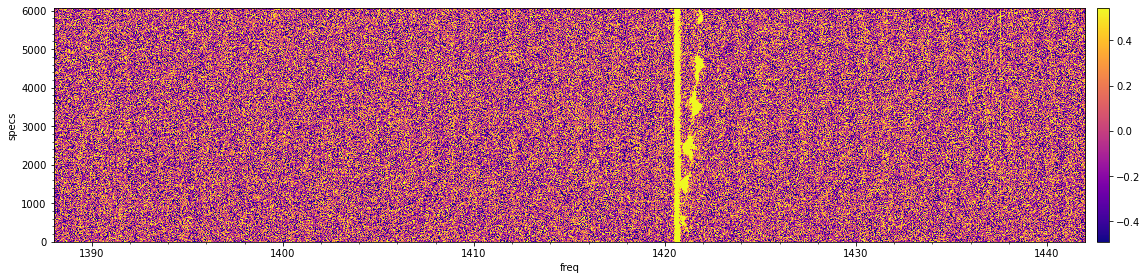

In [4]:
sub.plot_waterfall(data,per_vmin_max=.90,figsize=(18,4),cmap = 'plasma')

# RMS

目前rms可以手动指定选一个没有信号和干扰范围计算RMS。例如```--rms_frange 1410 1415```

如果不指定会自动寻找一个5MHz长没有干扰的区域，同时弹出一个info

In [5]:
import mpl_interactions.ipyplot as iplt

In [6]:
%matplotlib ipympl
spec = deepcopy(data[0,:])
def test_gauss(freq,sigma):
    from hifast.utils.misc import smooth1d
    sm = smooth1d(spec,method='gaussian',sigma=sigma)
    return sm

fig,ax = plt.subplots(figsize=(10,2))
iplt.plot(freq,spec,label = 'ori')
controls = iplt.plot(freq, test_gauss,  sigma=np.arange(2, 20, 1),xlim = [1410,1415],
                     ylim=[-1,1],color = 'C1',label='smooth')
iplt.title("sigma is {sigma:.2f}", controls=controls['sigma'])
plt.legend()
plt.show()

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

VBox()

(如果发现了交互没反应，重启内核并跳过前面画瀑布图即可

# MW range
有MW的区域，下面会被强制替代为驻波。例如下图的判断，如果输入了```--mw_frange 1420.3,1420.8```，那么MW将都被替代。注意过长将影响对驻波估计的效果，所以也可以不输入(None). 默认```[0,0]```

(1420.0, 1423.0)

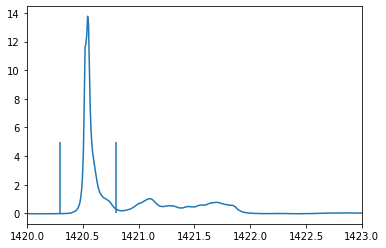

In [7]:
mw_frange = (1420.3,1420.8)
%matplotlib inline
plt.plot(freq,np.mean(data,axis = 0))
plt.vlines(mw_frange,ymin=0,ymax = 5)
plt.xlim(1420.0,1423)

接下来，考虑离散fourier变换的两端会拟合效果很差，可以在下一步切去两端或者在两端延长(未整合，但是测试过)，使得最终的结果保持良好的去驻波效果。这里不再演示

# Replace RFI or strong sources

这里'near ripple'使用高流量处附近的驻波替代源或RFI。例如
* `--times_thr`:大于RMS这么多倍的会被置为噪声(不平滑)
* `--times_s_thr`:大于RMS这么多倍的会被替代(第一次平滑)
* `--times_s_thr2`:大于RMS这么多倍的会被替代(第二次平滑)
* `--rfi_width_lim`: 要替换的rfi/源，频率上的宽度应该大于一阈值(通道数)
* `--ext_sec`: (接上面的)并向两边扩展通道数
* `--ext_freq`: 先扩展边缘(MHz)，再寻找强流量两边的最低点，先使用左/右边的一段更干净一点的代替强流量处，默认1.3即可


In [8]:
%matplotlib ipympl
from hifast.ripple.markRFI import real_rms,rms
def repalce_near_single(freq, times_s_thr=None,
                        times_s_thr2=None,times_thr=None, rms_sigma=None,ext_freq=None,
                        rms_frange=None, rfi_width_lim=None, ext_sec=None, 
                       ):
    fill = 'original'
    shift = 0
    """
    replace mw, rfi or others by near ripple section

    times_thr:above * times of rms will be lowered
    ext_freq: extend freq range to replace (mhz)
    rfi_width_lim:rfi should contain more channels than limit
    ext_sec: extend channel number of start and end of each section
    """
    fdelta = freq[1]-freq[0]

    ext = int(np.around(ext_freq / fdelta))

    from hifast.ripple.markRFI import real_std, real_rms, std, rms

#     newspec = np.full(data.shape[0], np.nan)
    MAX = np.nanmax(data)*20
    #################
    spec = deepcopy(data[tn, :])
    include = mw_use #| time_rfi[tn]
    if np.sum(include) > 0:
        spec[include] = MAX * 20   
    if times_s_thr2 is None: times_s_thr2 = times_s_thr

    RMS = rms(sm2, freq, rms_vrange=rms_frange)
    thr_s = RMS*times_s_thr2
    exceed_use = (np.abs(sm2) > thr_s) | time_rfi[tn]
    
    if sm3 is not None:
        restrict_use = (np.abs(sm3) > thr_s) | time_rfi[tn]
    else:
        restrict_use = np.full(freq.shape,True)
    STD = real_std(spec, freq, sigma = rms_sigma, vrange = rms_frange)
    newspec, rep_from, rep_to = replace_spec(tn, spec, freq, exceed_use, restrict_use, rfi_width_lim, ext_sec,
                           ext, STD, MAX, sm = sm1,test = True,fill = fill, shift = shift)

    RMS = real_rms(spec, freq, sigma=rms_sigma, rms_vrange=rms_frange)
    strange = np.where(np.abs(newspec) > times_thr * RMS)[0]
    newspec[strange] = np.random.normal(scale=RMS, size=len(strange))

    return newspec, rep_from, rep_to

# plot functions
def test_replace_new(freq, times_s_thr=None, times_s_thr2=None,times_thr=4, rms_sigma=6,ext_freq=1.3,
                        rms_frange=[1410,1415], rfi_width_lim=30, ext_sec=30,):
    newspec, rep_from, rep_to = repalce_near_single(freq, times_s_thr, times_s_thr2, times_thr, rms_sigma,ext_freq,
                        rms_frange, rfi_width_lim, ext_sec,)
    return newspec - offset * 2

def test_replace_from(freq, times_s_thr=None, times_s_thr2=None,times_thr=4, rms_sigma=6,ext_freq=1.3,
                        rms_frange=[1410,1415], rfi_width_lim=30, ext_sec=30,):
    newspec, rep_from, rep_to = repalce_near_single(freq, times_s_thr, times_s_thr2,times_thr, rms_sigma,ext_freq,
                        rms_frange, rfi_width_lim, ext_sec,)
    return rep_from

def test_replace_to(freq, times_s_thr=None, times_s_thr2=None,times_thr=4, rms_sigma=6,ext_freq=1.3,
                        rms_frange=[1410,1415], rfi_width_lim=30, ext_sec=30,):
    newspec, rep_from, rep_to = repalce_near_single(freq, times_s_thr, times_s_thr2,times_thr, rms_sigma,ext_freq,
                        rms_frange, rfi_width_lim, ext_sec,)
    return rep_to

def test_replace_thr(freq, times_s_thr=None, times_s_thr2=None,times_thr=4, rms_sigma=6,ext_freq=1.3,
                        rms_frange=[1410,1415], rfi_width_lim=30, ext_sec=30,):
    """thr"""
    RMS = real_rms(spec,freq,sigma=rms_sigma,rms_vrange=rms_frange)

    thr_lower = RMS*times_thr
    thr = np.full(len(freq),thr_lower)
    return thr

def test_replace_s_thr(freq, times_s_thr=None, times_s_thr2=None,times_thr=4, rms_sigma=6,ext_freq=1.3,
                        rms_frange=[1410,1415], rfi_width_lim=30, ext_sec=30,):
    """s_thr"""
    RMS = rms(sm2,freq,rms_vrange=rms_frange)
    
    thr_lower = RMS*times_s_thr
    thr = np.full(len(freq),thr_lower)
    return thr

def test_replace_s_thr2(freq, times_s_thr=None, times_s_thr2=None,times_thr=4, rms_sigma=6,ext_freq=1.3,
                        rms_frange=[1410,1415], rfi_width_lim=30, ext_sec=30,):
    """s_thr2"""
    RMS = rms(sm2,freq,rms_vrange=rms_frange)
    if times_s_thr2 is None: times_s_thr2 = times_s_thr
    thr_lower = RMS*times_s_thr2
    thr = np.full(len(freq),thr_lower)
    return thr - offset

def test_replace_s_thr3(freq, times_s_thr=None, times_s_thr2=None,times_thr=4, rms_sigma=6,ext_freq=1.3,
                        rms_frange=[1410,1415], rfi_width_lim=30, ext_sec=30,):
    """s_thr_res"""
    RMS = rms(sm2,freq,rms_vrange=rms_frange)
    if times_s_thr2 is None: times_s_thr2 = times_s_thr
    thr_lower = RMS*times_s_thr2
    thr = np.full(len(freq),thr_lower)
    return thr - offset * 2

def test_replace_diff(freq, times_s_thr=None, times_s_thr2=None,times_thr=4, rms_sigma=6,ext_freq=1.3,
                        rms_frange=[1410,1415], rfi_width_lim=30, ext_sec=30,):
    """difference"""
    newspec, rep_from, rep_to = repalce_near_single(freq, times_s_thr, times_s_thr2,times_thr, rms_sigma,ext_freq,
                        rms_frange, rfi_width_lim, ext_sec,)
    diff = ((spec - newspec) != 0)
    return diff * .5 - offset * 2

通过单条谱线尝试参数，划分被replace的范围.之前已经确定了rms_sigma=6,rms_frange=[1390,1400]，这里测试其他参数，使得不要替代过多的噪声而速度变慢。

# first iteration

第一次迭代。如果对弱源流量要求不高，可以不进行第二次迭代

首先,先进行第一次平滑，用于寻找需要替代的位置。使用了时间和频率两个方向，尽量保留弱源。对应`--s_method_t`,`--s_sifma_t`,`--s_method_freq`,`--s_sigma_freq`

In [9]:
import time
time_start = time.time()

sm_args = {}
sm_args['s_method_t'] = 'gaussian'
sm_args['s_sigma_t'] = 5
sm_args['s_method_freq'] = 'gaussian'
sm_args['s_sigma_freq'] = 3
sm_args['is_rfi'] = is_rfi
sm_args['is_on'] = is_on
data_find = do_smooth_onoff(data, **sm_args)

time_end = time.time()
print('Time cost = %fs' % (time_end - time_start))

Smoothing t ...
Smoothing freq ...
Smoothing t ...
Smoothing freq ...
Time cost = 8.173308s


第二次平滑，用于寻找驻波的波谷。如果不给定`--s_method_t_T`,`--s_sifma_t_T`,`--s_method_freq_T`,`--s_sigma_freq_T`,则使用与上一组相同的。

In [10]:
time_start = time.time()

sm_args = {}
sm_args['s_method_t'] = 'gaussian'
sm_args['s_sigma_t'] = 10
sm_args['s_method_freq'] = 'gaussian'
sm_args['s_sigma_freq'] = 5
sm_args['is_rfi'] = is_rfi
sm_args['is_on'] = is_on
data_trough = do_smooth_onoff(data, **sm_args)

time_end = time.time()
print('Time cost = %fs' % (time_end - time_start))

Smoothing t ...
Smoothing freq ...
Smoothing t ...
Smoothing freq ...
Time cost = 10.765565s


由于时间上的平滑可能扩大应该替代的区域，一旦`'s_method_t'!='none`且`restrict_bound = True`，将进行只有freq方向sigma为`rms_sigma`的第三次高斯平滑来限定替代区域。

In [11]:
sm_args = {}
sm_args['s_method_freq'] = 'gaussian'
sm_args['s_sigma_freq'] = 6
data_res = do_smooth_onoff(data, **sm_args)

Smoothing freq ...


可以分别尝试使用`mw_frange`与否的效果，**理论上不给MW范围限制更准**

mw_use = (freq > mw_frange[0])&(freq < mw_frange[1])

In [12]:
mw_use = np.full(freq.shape,False)

In [13]:
np.where(is_on)

(array([   4,    5,    6,    7,  604,  605,  606,  607, 1204, 1205, 1206,
        1207, 1804, 1805, 1806, 1807, 2404, 2405, 2406, 2407, 3004, 3005,
        3006, 3007, 3604, 3605, 3606, 3607, 4204, 4205, 4206, 4207, 4804,
        4805, 4806, 4807, 5404, 5405, 5406, 5407, 6004, 6005, 6006, 6007]),)

In [13]:
%matplotlib ipympl
offset = 1
xlim = [1415,1430]
ylim = [-3,3]

tn = 2000 # 根据噪音管开关可以尝试不同的tn
spec = deepcopy(data[tn])
sm1 = data_trough[tn] # 用于找波谷
sm2 = data_find[tn] # 用于找要替代的区域
sm3 = data_res[tn] # 用于限制要替代的范围，防止替代过多

fig = plt.figure(figsize=(15,4))
ax = fig.add_subplot(111)
iplt.plot(freq,spec,label='original',alpha = .5)
plt.plot(freq,is_rfi[tn]*.08,'k',alpha=.5,label='is_rfi')

ax.plot(freq,sm1,'m',alpha=.5,label='trough')  # 用于找波谷
# iplt.plot(freq,mw_use*1.5,label='mw',alpha = .5)
controls = iplt.plot(freq, test_replace_to,
                     times_thr=np.arange(1.,10,.25),
                     times_s_thr=np.arange(0.2,8,.2),
#                      times_s_thr2=np.arange(1.8 ,6,.2), 第一次替代不使用此参数
                     rfi_width_lim=np.arange(2,50,2).astype(int), 
                     ext_sec=np.arange(2,50,2).astype(int),
                     ext_freq=np.arange(1.3,5,0.1),
                     xlim=xlim,ylim=ylim,label='rep to')
iplt.plot(freq,test_replace_from,controls = controls,
                     alpha=.8,xlim=xlim,ylim=ylim,label = 'copy from') # 这里是邻近的驻波
iplt.plot(freq,test_replace_new,controls = controls, c='g',
                     alpha=.5,xlim=xlim,ylim=ylim,label = 'after replace') # 要复制到这里，他们共用一个波谷
iplt.plot(freq,test_replace_diff,'r--',controls = controls,
                     alpha=.5,xlim=xlim,ylim=ylim,label = 'rep area') # 最后被替代/填噪声的区域

ax.plot(freq,sm2 - offset,'m-.',alpha=.5,label='find') # 用于找要替代的区域
ax.plot(freq,sm3 - offset * 2,'m--',alpha=.5,label='restrict') # 用于限制要替代的范围，防止替代过多

iplt.plot(freq,test_replace_thr,'k:',controls = controls,
                     alpha=.5,xlim=xlim,ylim=ylim,label = 'thr') # 不平滑的阈值，识别异常值(比如narrow band RFI)
iplt.plot(freq,test_replace_s_thr,'k--',controls = controls,
                     alpha=.5,xlim=xlim,ylim=ylim,label = 's_thr') # 第一次迭代中平滑的阈值，用于找波谷
iplt.plot(freq,test_replace_s_thr2,'k-.',controls = controls,
                     alpha=.5,xlim=xlim,ylim=ylim,label = 's_thr2') # 这里不使用第二次迭代的阈值，所以与times_s_thr一样，只是用于找要替代的区域
iplt.plot(freq,test_replace_s_thr3,'k',controls = controls, ls = (0, (3, 1, 1, 1, 1, 1)),# 'densely dashdotdotted'
                     alpha=.5,xlim=xlim,ylim=ylim,label = 's_thr_res') # 这个阈值用于限制要替代的范围，防止替代过多。也与times_s_thr一样
ax.grid();ax.legend(loc='right')
plt.show()

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

VBox()

## replace
前面确定好了参数，现在处理所有谱线

In [14]:
rep_args = {}
rep_args['rms_sigma'] = 6
rep_args['rms_frange'] = [1410, 1415]
rep_args['times_thr'] = 4
rep_args['times_s_thr'] = 3
# rep_args['times_s_thr2'] = 2 # 第二次迭代参数在第一次不使用
rep_args['rfi_width_lim'] = 20
rep_args['ext_sec'] = 30
rep_args['ext_freq'] = 1.3
# rep_args['mw_frange'] = mw_frange

In [15]:
data_rep, is_excluded = replace_rfi(data, freq, time_rfi=is_rfi, method='near_ripple',save_is_excluded = False,
                                 data_find = data_find, data_trough = data_trough, data_restrict = data_res, **rep_args)

INFO: Replace RFI with near_ripple method ... [hifast.ripple.sw_fft]


100%|██████████| 6057/6057 [00:13<00:00, 439.35it/s]


`is_excluded`试图包含rfi和可能是源的部分，如果去驻波但不去基线(sw_nobld)，下一步再去基线(bld)，bld.py会读取其中的`is_excluded`，防止基线对信号的过拟合(但是此参数还需要更多测试)

`is_excluded`在第二次迭代中生成，所以这里是None

In [16]:
is_excluded 

array([None], dtype=object)

替代后瀑布图的效果

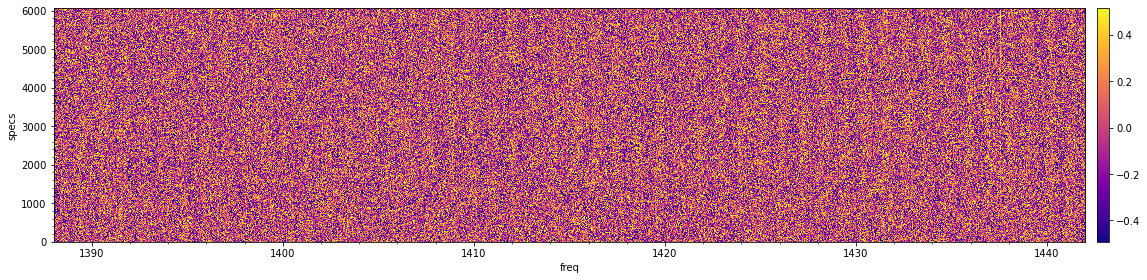

In [18]:
%matplotlib inline
sub.plot_waterfall(data_rep,per_vmin_max=.90,figsize=(18,4),cmap = 'plasma')

# FFT remove 1MHz ripples

第一次迭代中的去驻波

* ```--sw_base```: 去除傅里叶空间的常数成分。如果基线整体偏离0, 此参数设为True可缓解。
* ```--sw_periods```: 去除的驻波成分。后可接多个字符。默认为```1mhz 2mhz 0_04mhz```. 字符与对应的驻波周期为：
   * 字符: 驻波周期
   * 1mhz: 1.08mhz
   * 2mhz: 1.92mhz
   * 0_04mhz: 0.039 mhz

* ```--check_2mhz```: 若为True，如果输入Beam 6文件，将在```--sw_periods```中添加'2mhz', 如果输入的不是Beam 6文件，则删除'2mhz'(如果存在)。因为'2mhz'驻波目前只存在于Beam 6 中。
* ```--amp_thr_mean_factor```: 傅里叶空间的平均振幅大于阈值的模，会被识别为已知的几种驻波。这里输入的是中值的倍数。输入时noise on/off分别对应两个阈值
* ```--amp_thr_solo_factor```: 傅里叶空间的每一谱线的振幅大于阈值，会被选中为驻波一部分被去除。这里输入的是中值的倍数。输入时noise on/off分别对应两个阈值
* ```--chan_wide```: 距离驻波的模的中心左右各(2 * chann - 1)个通道数的模，作为驻波的一部分被选中. 用于'1mhz'和'2mhz'的驻波。默认为5
* ```--chan_narr```: 同上，窄一些的. 用于'0_04mhz'的驻波。默认为3
* ```--choose_method```: 选择傅里叶空间中哪些模作为驻波的方法，'all'或者'interpolate'. 默认为'all'.

## Noise off

然后对data_rep进行FFT

In [17]:
divide_warning = np.seterr(divide='ignore')

In [18]:
from hifast.ripple.sw_fft import *
sw = SW_FFT(data_rep[~is_on], freq, 10)
sw.do_fft()
x = sw.x
amp_data = sw.amp
amp_mean = np.nanmean(amp_data,axis=0)
is_excluded_mean = np.all(is_rfi[~is_on], axis=1) # 严重RFI的谱线不会参与振幅平均

Text(0.5, 24.0, 't [$\\mu s$]')

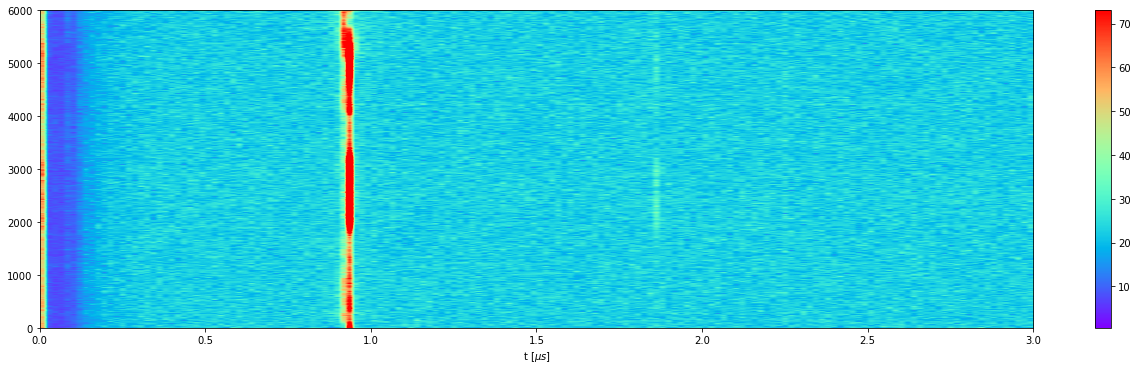

In [23]:
%matplotlib inline
plt.figure(figsize=(18,5))
vmin,vmax = percent_vminmax(amp_data,percent = .999)
plt.imshow(amp_data,origin='lower',aspect='auto',extent=(x[0],x[-1],0,amp_data.shape[0]),
        vmin=vmin,vmax=vmax,cmap='rainbow')

plt.tight_layout()
plt.colorbar()
plt.xlim(0,3)
plt.xlabel("t [$\mu s$]")

这里先给出Fourier空间中取模的成分范围，单位是通道数，分宽和窄两种

In [19]:
chan_wide=4 # 这是半宽
chan_narr=2
cw = 2 * chan_wide - 1
cn = 2 * chan_narr - 1
print(f"all_chan_wide = {cw}, all_chan_narrow = {cn}")

all_chan_wide = 7, all_chan_narrow = 3


内置的驻波种类，在$\mu$s轴上的大概范围，和选取的最大半通道数

In [20]:
sw_periods=['1mhz', '2mhz', '0_04mhz']
sw_conf = get_sw_conf(chan_wide, chan_narr)
sw_conf

{'1mhz': {'xlims': [[0.9, 0.95], [1.8, 1.9]], 'nchans': [4, 2]},
 '2mhz': {'xlims': [[0.5, 0.6]], 'nchans': [4]},
 '0_04mhz': {'xlims': [[25, 26]], 'nchans': [2]}}

通过平均所有振幅，决定该波束存在哪些驻波

In [21]:
def test_amp_mean(x,amp_thr_mean_factor):
    sw.gen_amp_thr_s(amp_thr_mean_factor,amp_thr_solo_factor=1.4,is_excluded_mean=is_excluded_mean)
    loc = []
    for key in sw_periods:
        sw.find_sw_loc(xlims=sw_conf[key]['xlims'])
        if np.sum(sw.bingo_list) > 1:
            for b in range(len(sw.bingo_list)):
                if sw.bingo_list[b]:
                    loc += [sw.loc_list[b],]
    if len(loc)>0: loc = np.hstack((loc))
    select = np.full(x.shape,np.nan)
    
    select[loc] = 5 # modify plot height
    print("---------------------------------")
    return select

def test_amp_mean_line(x,amp_thr_mean_factor):
    amp_thr = sw.amp_thr_mean
    return np.full(len(x),amp_thr)

改变这里的amp_thr_mean_factor，选择的驻波数量会变化(print的变化在log窗口里)

In [22]:
%matplotlib ipympl
ylim=[0,50]
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(211) 
ax.set_xlim(-.01,2)
iplt.plot(x,amp_mean,'.-', label = 'amp mean')
controls = iplt.plot(x,test_amp_mean,'^',
                     amp_thr_mean_factor=np.arange(1,1.7,0.0015),
                     xlim=[-.01,2],ylim=ylim,label='selected')
iplt.plot(x,test_amp_mean_line,'k--',controls=controls,
                     alpha=.5,xlim=[-.01,2],ylim=ylim,label = 'thr')
ax.grid();ax.legend(loc = 2)
ax.set_xlabel('t [$\mu$s]')
ax.set_ylabel('amp')

ax = fig.add_subplot(212) 
iplt.plot(x,amp_mean,'.-', label = 'amp mean')
iplt.plot(x,test_amp_mean,'^',controls=controls,
                     xlim=[25,26],ylim=ylim,label='selected')
iplt.plot(x,test_amp_mean_line,'k--',controls=controls,
                      alpha=.5,xlim=[25,26],ylim=ylim,label = 'thr')
ax.set_xlim(25,26)
ax.grid();ax.legend(loc = 2)
ax.set_xlabel('t [$\mu$s]')
ax.set_ylabel('amp')
plt.tight_layout()

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

VBox()

find ripple 1.08002 MHz,0.92591 mu s,locate in 50
find ripple 0.54001 MHz,1.85182 mu s,locate in 100
find ripple 1.86210 MHz,0.53703 mu s,locate in 29
find ripple 0.03879 MHz,25.77737 mu s,locate in 1392
---------------------------------


VBox()

find ripple 1.08002 MHz,0.92591 mu s,locate in 50
find ripple 0.54001 MHz,1.85182 mu s,locate in 100
find ripple 1.86210 MHz,0.53703 mu s,locate in 29
find ripple 0.03879 MHz,25.77737 mu s,locate in 1392
---------------------------------


从平均的fourier模，可以看出明显的几种驻波，1mhz和它的倍频0.54mhz

同理，决定单条谱线适用的阈值倍数amp_thr_factor和取模通道数，chan_wide,chan_narr。这里可视化测试off的谱线举例

In [23]:
def test_amp_solo(x,amp_thr_mean_factor,amp_thr_solo_factor,chan_wide,chan_narr):

    sw_conf1 = get_sw_conf(chan_wide, chan_narr)
    sw.gen_amp_thr_s(amp_thr_mean_factor,amp_thr_solo_factor,is_excluded_mean=is_excluded_mean)
    
    sw.is_use_sw_chan = np.full(x.shape,False)
    for key in sw_periods:
        sw.find_sw_loc(xlims=sw_conf1[key]['xlims'])
        sw.find_sw_chans(nchans=sw_conf1[key]['nchans'])
        is_use_sw_chan_amp = sw.is_use_sw_chan & (amp_data[tn] > sw.amp_thr_solo)
    
    select = np.zeros_like(x)   
    select[is_use_sw_chan_amp] = amp_data[tn][is_use_sw_chan_amp] 
    print("---------------------------------")
    return select


def test_amp_solo_line(x,amp_thr_mean_factor,amp_thr_solo_factor,chan_wide,chan_narr):
    amp_thr = sw.amp_thr_solo
    return np.full(len(x),amp_thr)

dx = x[1] - x[0]

In [24]:
tn = 0
%matplotlib ipympl
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(211) 
xlim=[-.01,2];ylim=[0,100]
iplt.plot(x,amp_data[tn],'.-', label = f'amp tn = {tn}')
controls = iplt.plot(x,test_amp_solo,
                     amp_thr_mean_factor=1.05, # 已经固定
                     amp_thr_solo_factor=np.arange(1,2,0.02),
                     chan_wide=np.arange(1,9),chan_narr=np.arange(1,5),
                     xlim=xlim,ylim=ylim,label='selected')
iplt.plot(x,test_amp_solo_line,'k--',controls=controls,
                     alpha=.5,xlim=xlim,ylim=ylim,label = 'thr')
ax.grid();ax.legend(loc = 2)
ax.set_xlabel('t [$\mu$s]')
ax.set_ylabel('amp')

xlim=[25,26]
ax = fig.add_subplot(212) 
iplt.plot(x,amp_data[tn], label = f'amp tn = {tn}')
iplt.plot(x,test_amp_solo,controls=controls,
                     xlim=xlim,ylim=ylim,label='selected')
iplt.plot(x,test_amp_solo_line,'k--',controls=controls,
                      alpha=.5,xlim=xlim,ylim=ylim,label = 'thr')
ax.grid();ax.legend(loc = 2)
ax.set_xlabel('t [$\mu$s]')
ax.set_ylabel('amp')
plt.tight_layout()

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

VBox()

find ripple 1.08002 MHz,0.92591 mu s,locate in 50
find ripple 0.54001 MHz,1.85182 mu s,locate in 100
---------------------------------


VBox()

find ripple 1.08002 MHz,0.92591 mu s,locate in 50
find ripple 0.54001 MHz,1.85182 mu s,locate in 100
---------------------------------


## Noise on

相同的调整参数方法

In [25]:
from hifast.ripple.sw_fft import *
sw = SW_FFT(data_rep[is_on], freq, 10)
sw.do_fft()
x = sw.x
amp_data = sw.amp
amp_mean = np.nanmean(amp_data,axis=0)
is_excluded_mean = np.all(is_rfi[is_on], axis=1) # 严重RFI的谱线不会参与振幅平均

Text(0.5, -3.0, 't [$\\mu s$]')

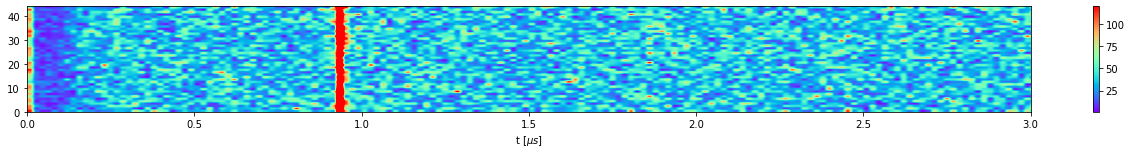

In [26]:
%matplotlib inline
plt.figure(figsize=(18,2))
vmin,vmax = percent_vminmax(amp_data,percent = .999)
plt.imshow(amp_data,origin='lower',aspect='auto',extent=(x[0],x[-1],0,amp_data.shape[0]),
        vmin=vmin,vmax=vmax,cmap='rainbow')

plt.tight_layout()
plt.colorbar()
plt.xlim(0,3)
plt.xlabel("t [$\mu s$]")

In [27]:
%matplotlib ipympl
ylim=[0,80]
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(211) 
ax.set_xlim(-.01,2)
iplt.plot(x,amp_mean,'.-', label = 'amp mean')
controls = iplt.plot(x,test_amp_mean,'^',
                     amp_thr_mean_factor=np.arange(1,1.7,0.0015),
                     xlim=[-.01,2],ylim=ylim,label='selected')
iplt.plot(x,test_amp_mean_line,'k--',controls=controls,
                     alpha=.5,xlim=[-.01,2],ylim=ylim,label = 'thr')
ax.grid();ax.legend(loc = 2)
ax.set_xlabel('t [$\mu$s]')
ax.set_ylabel('amp')

ax = fig.add_subplot(212) 
iplt.plot(x,amp_mean,'.-', label = 'amp mean')
iplt.plot(x,test_amp_mean,'^',controls=controls,
                     xlim=[25,26],ylim=ylim,label='selected')
iplt.plot(x,test_amp_mean_line,'k--',controls=controls,
                      alpha=.5,xlim=[25,26],ylim=ylim,label = 'thr')
ax.set_xlim(25,26)
ax.grid();ax.legend(loc = 2)
ax.set_xlabel('t [$\mu$s]')
ax.set_ylabel('amp')
plt.tight_layout()

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

VBox()

find ripple 1.08002 MHz,0.92591 mu s,locate in 50
find ripple 0.54001 MHz,1.85182 mu s,locate in 100
find ripple 1.68753 MHz,0.59258 mu s,locate in 32
find ripple 0.03982 MHz,25.11071 mu s,locate in 1356
---------------------------------


VBox()

find ripple 1.08002 MHz,0.92591 mu s,locate in 50
find ripple 0.54001 MHz,1.85182 mu s,locate in 100
find ripple 1.68753 MHz,0.59258 mu s,locate in 32
find ripple 0.03982 MHz,25.11071 mu s,locate in 1356
---------------------------------


In [28]:
tn = 1
%matplotlib ipympl
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(211) 
xlim=[-.01,2];ylim=[0,150]
iplt.plot(x,amp_data[tn],'.-', label = f'amp tn = {tn}')
controls = iplt.plot(x,test_amp_solo,
                     amp_thr_mean_factor=1.3, # 已经固定
                     amp_thr_solo_factor=np.arange(1,2,0.02),
                     chan_wide=np.arange(1,9),chan_narr=np.arange(1,5),
                     xlim=xlim,ylim=ylim,label='selected')
iplt.plot(x,test_amp_solo_line,'k--',controls=controls,
                     alpha=.5,xlim=xlim,ylim=ylim,label = 'thr')
ax.grid();ax.legend(loc = 2)
ax.set_xlabel('t [$\mu$s]')
ax.set_ylabel('amp')

xlim=[25,26]
ax = fig.add_subplot(212) 
iplt.plot(x,amp_data[tn], label = f'amp tn = {tn}')
iplt.plot(x,test_amp_solo,controls=controls,
                     xlim=xlim,ylim=ylim,label='selected')
iplt.plot(x,test_amp_solo_line,'k--',controls=controls,
                      alpha=.5,xlim=xlim,ylim=ylim,label = 'thr')
ax.grid();ax.legend(loc = 2)
ax.set_xlabel('t [$\mu$s]')
ax.set_ylabel('amp')
plt.tight_layout()

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

VBox()

find ripple 1.08002 MHz,0.92591 mu s,locate in 50
find ripple 0.54001 MHz,1.85182 mu s,locate in 100
---------------------------------


VBox()

find ripple 1.08002 MHz,0.92591 mu s,locate in 50
find ripple 0.54001 MHz,1.85182 mu s,locate in 100
---------------------------------


对于测试数据，我选择了以下参数.`choose_method`有选择所有模'all'和线性插值'interpolate'两种方式，可以分别尝试效果。

## 现在使用完整的函数进行测试

In [29]:
fft_args_off = {}
fft_args_off['amp_thr_mean_factor'] = 1.05
fft_args_off['amp_thr_solo_factor'] = 1.4
fft_args_off['chan_wide'] = 4
fft_args_off['chan_narr'] = 2
fft_args_off['choose_method'] = 'all'
fft_args_off['sw_periods'] = ['1mhz', '2mhz', '0_04mhz']
fft_args_off['sw_base'] = True
fft_args_off['is_excluded_mean'] = np.all(is_rfi[~is_on], axis=1)

sw_data_off = fit_sw_fft(data_rep[~is_on], freq, nproc=10,  **fft_args_off)

find ripple 1.08002 MHz,0.92591 mu s,locate in 50
find ripple 0.54001 MHz,1.85182 mu s,locate in 100


In [30]:
fft_args_on = deepcopy(fft_args_off)
fft_args_on['amp_thr_mean_factor'] = 1.3
fft_args_on['amp_thr_solo_factor'] = 1.7
fft_args_on['is_excluded_mean'] = np.all(is_rfi[is_on], axis=1)
sw_data_on = fit_sw_fft(data_rep[is_on], freq, nproc=10,  **fft_args_on)

find ripple 1.08002 MHz,0.92591 mu s,locate in 50
find ripple 0.54001 MHz,1.85182 mu s,locate in 100


In [31]:
sw_data = np.zeros_like(data) # 驻波
sw_data[is_on] = sw_data_on
sw_data[~is_on] = sw_data_off

rmsw_data = data - sw_data # remove standing waves之后的结果

下面可以画一下单条谱线的效果

In [37]:
from hifast.utils.misc import smooth1d

Text(0.5, 1.0, 'one spec, polar yy')

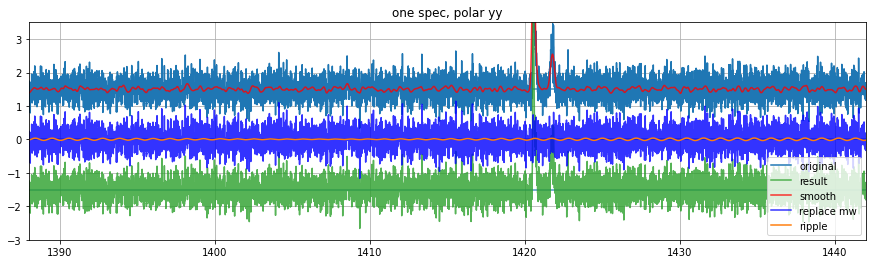

In [38]:
%matplotlib inline
offset = 1.5

tn = 4500
fig = plt.figure(figsize=(15,4))
ax = fig.add_subplot(111)
ax.hlines([0,-offset, offset],freq[0],freq[-1],alpha = .8)
ax.plot(freq,data[tn] + offset,label='original')
ax.plot(freq,rmsw_data[tn] - offset,label='result',c='C2',alpha = .8)
ax.plot(freq,smooth1d(data[tn],method='gaussian', sigma=10) +offset,'r',label = 'smooth',alpha = .8)
ax.plot(freq,data_rep[tn],'b',label='replace mw',alpha = .8)
ax.plot(freq,sw_data[tn],c= 'C1',label='ripple')
ax.set_xlim(freq[0],freq[-1])
ax.set_ylim(-3,3.5) 
ax.grid();ax.legend();ax.set_title(f'one spec, polar yy')

平均10条谱线效果更明显，降低了很多

Text(0.5, 1.0, 'ten specs mean, polar yy')

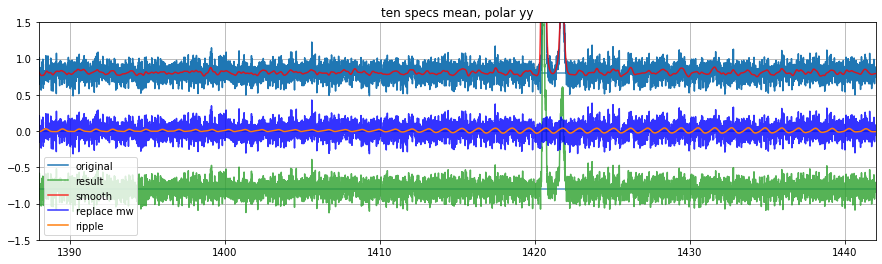

In [39]:
%matplotlib inline
offset = .8

fig = plt.figure(figsize=(15,4))
ax = fig.add_subplot(111)
ax.hlines([0,-offset, offset],freq[0],freq[-1],alpha = .8)
ax.plot(freq,np.mean(data[tn-5:tn+5],axis=0)+offset,label='original')
ax.plot(freq,np.mean(rmsw_data[tn-5:tn+5],axis=0) -offset,label='result',c='C2',alpha = .8)
ax.plot(freq,np.mean(smooth1d(data[tn-5:tn+5],method='gaussian', sigma=10),axis=0) +offset,'r',label = 'smooth',alpha = .8)
ax.plot(freq,np.mean(data_rep[tn-5:tn+5],axis=0),'b',label='replace mw',alpha = .8)
ax.plot(freq,np.mean(sw_data[tn-5:tn+5],axis=0),c= 'C1',label='ripple')
ax.set_xlim(freq[0],freq[-1])
ax.set_ylim(-1.5,1.5) 
ax.grid();ax.legend();ax.set_title(f'ten specs mean, polar yy')

瀑布图效果

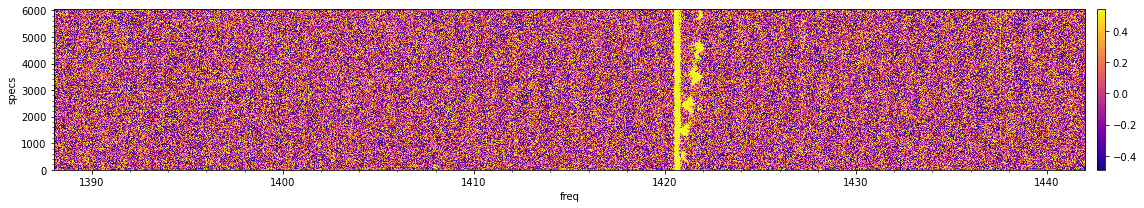

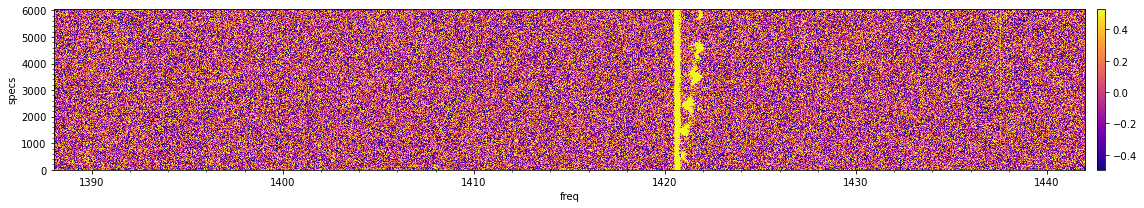

In [31]:
sub.plot_waterfall(data,per_vmin_max=.90,figsize=(18,3),cmap = 'plasma')
sub.plot_waterfall(rmsw_data,per_vmin_max=.90,figsize=(18,3),cmap = 'plasma')

# second iteration

第二次迭代,对上面输出的再进行平滑

In [32]:
sm_args = {}
sm_args['s_method_t'] = 'gaussian'
sm_args['s_sigma_t'] = 5
sm_args['s_method_freq'] = 'gaussian'
sm_args['s_sigma_freq'] = 3
sm_args['is_rfi'] = is_rfi
sm_args['is_on'] = is_on
data_find = do_smooth_onoff(rmsw_data, **sm_args)

sm_args = {}
sm_args['s_method_freq'] = 'gaussian'
sm_args['s_sigma_freq'] = 6
data_res = do_smooth_onoff(rmsw_data, **sm_args)

Smoothing t ...
Smoothing freq ...
Smoothing t ...
Smoothing freq ...
Smoothing freq ...


## replace

In [33]:
%matplotlib ipympl
offset = 1
xlim = [1415,1430]
ylim = [-3,3]

tn = 2000 # 根据噪音管开关可以尝试不同的tn
spec = deepcopy(data[tn])
sm1 = data_trough[tn] # 用于找波谷
sm2 = data_find[tn] # 用于找要替代的区域
sm3 = data_res[tn] # 用于限制要替代的范围，防止替代过多

fig = plt.figure(figsize=(15,4))
ax = fig.add_subplot(111)
iplt.plot(freq,spec,label='original',alpha = .5)
plt.plot(freq,is_rfi[tn]*.08,'k',alpha=.5,label='is_rfi')

ax.plot(freq,sm1,'m',alpha=.5,label='trough')  # 用于找波谷
# iplt.plot(freq,mw_use*1.5,label='mw',alpha = .5)
controls = iplt.plot(freq, test_replace_to,
                     times_thr=4,                                     # 前面已经固定了
                     times_s_thr=3,                                   # 前面已经固定了
                     times_s_thr2=np.arange(1.8 ,6,.2),
                     rfi_width_lim=np.arange(2,50,2).astype(int), 
                     ext_sec=np.arange(2,50,2).astype(int),
                     ext_freq=np.arange(1.3,5,0.1),
                     xlim=xlim,ylim=ylim,label='rep to')
iplt.plot(freq,test_replace_from,controls = controls,
                     alpha=.8,xlim=xlim,ylim=ylim,label = 'copy from') # 这里是邻近的驻波
iplt.plot(freq,test_replace_new,controls = controls, c='g',
                     alpha=.5,xlim=xlim,ylim=ylim,label = 'after replace') # 要复制到这里，他们共用一个波谷
iplt.plot(freq,test_replace_diff,'r--',controls = controls,
                     alpha=.5,xlim=xlim,ylim=ylim,label = 'rep area') # 最后被替代/填噪声的区域

ax.plot(freq,sm2 - offset,'m-.',alpha=.5,label='find') # 用于找要替代的区域
ax.plot(freq,sm3 - offset * 2,'m--',alpha=.5,label='restrict') # 用于限制要替代的范围，防止替代过多

iplt.plot(freq,test_replace_thr,'k:',controls = controls,
                     alpha=.5,xlim=xlim,ylim=ylim,label = 'thr') # 不平滑的阈值，识别异常值(比如narrow band RFI)。已经固定
iplt.plot(freq,test_replace_s_thr,'k--',controls = controls,
                     alpha=.5,xlim=xlim,ylim=ylim,label = 's_thr') # 第一次迭代中平滑的阈值。已经固定
iplt.plot(freq,test_replace_s_thr2,'k-.',controls = controls,
                     alpha=.5,xlim=xlim,ylim=ylim,label = 's_thr2') # 第二次迭代中平滑的阈值，用于找要替代的区域
iplt.plot(freq,test_replace_s_thr3,'k',controls = controls, ls = (0, (3, 1, 1, 1, 1, 1)),# 'densely dashdotdotted'
                     alpha=.5,xlim=xlim,ylim=ylim,label = 's_thr_res') # 这个阈值用于限制要替代的范围，防止替代过多.与times_s_thr2一样
ax.grid();ax.legend(loc='right')
plt.show()

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

VBox()

In [34]:
rep_args

{'rms_sigma': 6,
 'rms_frange': [1410, 1415],
 'times_thr': 4,
 'times_s_thr': 3,
 'rfi_width_lim': 20,
 'ext_sec': 30,
 'ext_freq': 1.3}

使用此参数再replace，FFT

In [35]:
rep_args['times_s_thr2'] = 2
rep_args['save_is_excluded'] = True
data_rep2, is_excluded = replace_rfi(data, freq, time_rfi=is_rfi, method='near_ripple', 
                                 data_find = data_find, data_trough = data_trough, data_restrict = data_res, **rep_args)

INFO: Replace RFI with near_ripple method ... [hifast.ripple.sw_fft]


100%|██████████| 6057/6057 [00:16<00:00, 367.51it/s]


In [36]:
sw_data_off = fit_sw_fft(data_rep2[~is_on], freq, nproc=10,  **fft_args_off)
sw_data_on = fit_sw_fft(data_rep2[is_on], freq, nproc=10,  **fft_args_on)

sw_data2 = np.zeros_like(data) # 驻波
sw_data2[is_on] = sw_data_on
sw_data2[~is_on] = sw_data_off

rmsw_data2 = data - sw_data2 # remove standing waves之后的结果

find ripple 1.08002 MHz,0.92591 mu s,locate in 50
find ripple 0.54001 MHz,1.85182 mu s,locate in 100
find ripple 1.08002 MHz,0.92591 mu s,locate in 50
find ripple 0.54001 MHz,1.85182 mu s,locate in 100


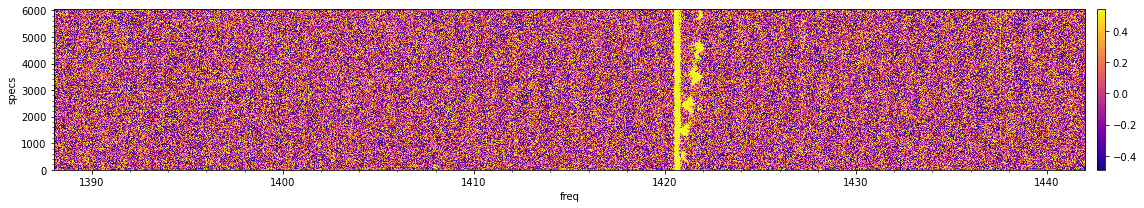

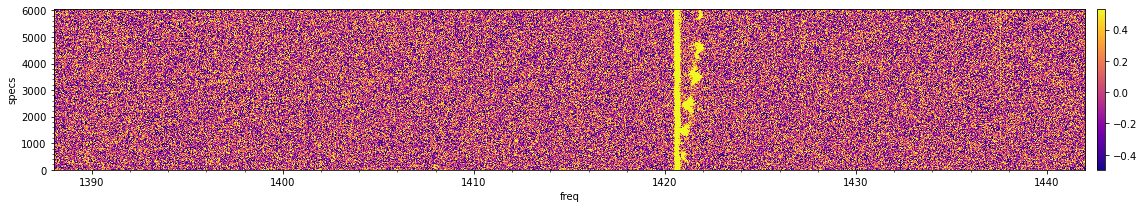

In [37]:
%matplotlib inline
sub.plot_waterfall(data,per_vmin_max=.90,figsize=(18,3),cmap = 'plasma')
sub.plot_waterfall(rmsw_data2,per_vmin_max=.90,figsize=(18,3),cmap = 'plasma')

迭代的区别其实很小

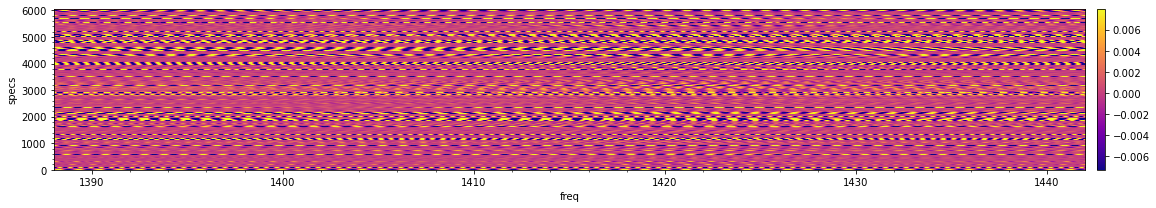

In [38]:
sub.plot_waterfall(rmsw_data2 - rmsw_data,per_vmin_max=.90,figsize=(18,3),cmap = 'plasma')

还得到了一个mask

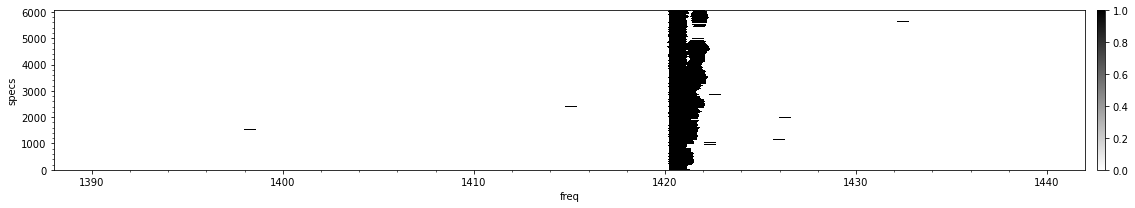

In [40]:
sub.plot_waterfall(is_excluded,figsize=(18,3),cmap = 'gray_r')

# Run .ini

In [1]:
subname = '/data/inspur_disk01/userdir/xuc/FAST/M33/new_21/OTF_h/rfi/M33_OTF_1_MultiBeamOTF-M01_W-20210731-specs_T-bld-rfi.hdf5'

In [2]:
!python -m hifast.sw $subname -c ./conf/S4-sw.ini -f --outdir ./data_S/

###################################Args###################################
Command Line Args:   /data/inspur_disk01/userdir/xuc/FAST/M33/new_21/OTF_h/rfi/M33_OTF_1_MultiBeamOTF-M01_W-20210731-specs_T-bld-rfi.hdf5 -c ./conf/S4-sw.ini -f --outdir ./data_S/
Config File (./conf/S4-sw.ini):
  frange:            ['0', 'inf']
  nproc:             10
  s_method_t:        gaussian
  s_sigma_t:         5
  s_method_freq:     gaussian
  s_sigma_freq:      3
  s_method_t_T:      gaussian
  s_sigma_t_T:       10
  s_method_freq_T:   gaussian
  s_sigma_freq_T:    5
  method:            fft
  nobld:             False
  njoin:             10
  exclude_m:         0
  sin_f:             0.929
  bound_f:           [0.9, 0.95]
  deg:               1
  iter_twice:        True
  rfi_method:        near_ripple
  rms_sigma:         6
  rms_step:          5
  times_thr:         4
  times_s_thr:       3
  times_s_thr2:      2
  ext_freq:          1.3
  rfi_width_lim:     20
  ext_sec:           30
  restrict_bo

In [5]:
from hifast.ripple.util import Read_hdf5, Args
name = './data_S/M33_OTF_1_MultiBeamOTF-M01_W-20210731-specs_T-bld-rfi-sw.hdf5'
f = Read_hdf5(Args(name))

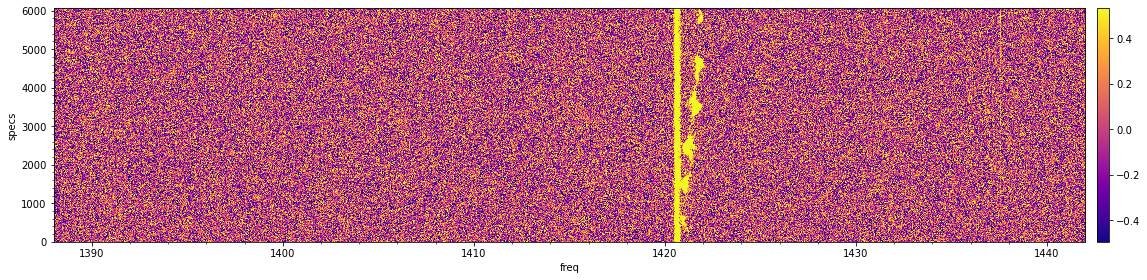

In [9]:
T = f.get_data(polar='xx')
f.plot_waterfall(T, per_vmin_max=.90,figsize=(18,4),cmap = 'plasma',)

嗯，确实去除了驻波。但是注意两边会变差，因为对于DFT，两边是截断。